# Proyecto 11: Aprendizaje Supervisado
Objetivos:
- Predecir si un cliente dejará el banco pronto
- F1 de al menos 0.59
- Medir la métrica AUC-ROC y compararla con el valor F1

In [31]:
# Librerías, en orden de uso:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

random_state = 1492

## Importación de Datos y Descripción

In [2]:
df = pd.DataFrame(pd.read_csv('/datasets/Churn.csv'))
print(df.head())
print(df.info())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0     2.0       0.00              1          1               1   
1     1.0   83807.86              1          0               1   
2     8.0  159660.80              3          1               0   
3     1.0       0.00              2          0               0   
4     2.0  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

In [3]:
df['CustomerId'] = df['CustomerId'].astype(str)
print(df['CustomerId'].duplicated().sum())

0


In [4]:
df['Surname'].nunique()

2932

In [5]:
print(df['Geography'].unique().tolist(), sep=', ')

['France', 'Spain', 'Germany']


In [6]:
print(df['Gender'].unique().tolist(), sep=', ')

['Female', 'Male']


In [7]:
print(df['Age'].describe())

count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: Age, dtype: float64


count    9091.000000
mean        4.997690
std         2.894723
min         0.000000
25%         2.000000
50%         5.000000
75%         7.000000
max        10.000000
Name: Tenure, dtype: float64 

Moda de tenencia: 1.0


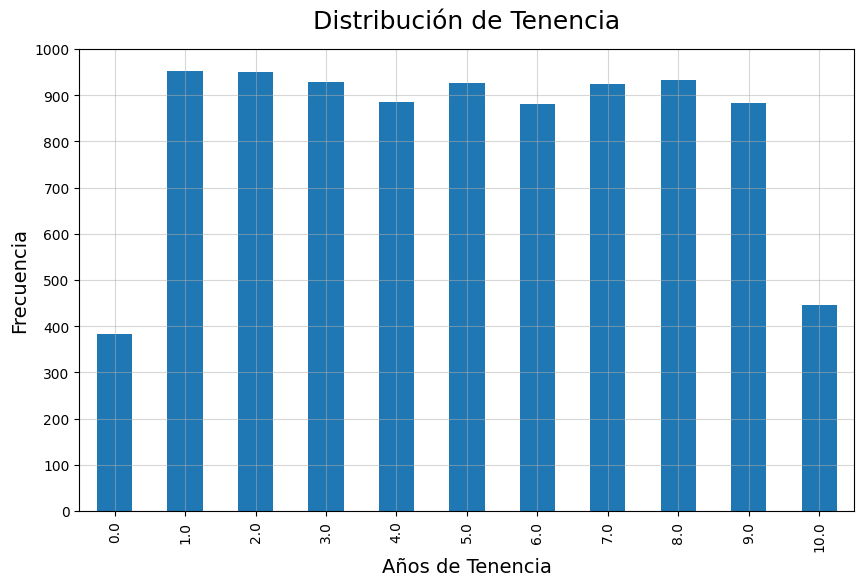

In [8]:
print(df['Tenure'].describe(), '\n')
print(f"""Moda de tenencia: {df['Tenure'].mode().iloc[0]}""") # Solo había un valor, así que use iloc para obtener el número solamente.

df['Tenure'].value_counts().sort_index().plot(
    figsize=(10, 6),
    kind='bar',
    ylim=[0,1000]
)
plt.title('Distribución de Tenencia', fontsize=18, pad=15)
plt.xlabel('Años de Tenencia', fontsize=14)
plt.ylabel('Frecuencia', fontsize=14)
plt.grid(alpha=0.5)
plt.yticks(np.arange(0, 1001, 100))
plt.show()

In [9]:
print(df['Balance'].describe(), '\n')
print(f"""Moda de balance: $ {df['Balance'].mode().iloc[0]} \n""")  # Solo había un valor, así que use iloc para obtener el número solamente.
print(f"""Coeficiente de Variación: {df['Balance'].std()/df['Balance'].mean()*100:.2f} %""")

count     10000.000000
mean      76485.889288
std       62397.405202
min           0.000000
25%           0.000000
50%       97198.540000
75%      127644.240000
max      250898.090000
Name: Balance, dtype: float64 

Moda de balance: $ 0.0 

Coeficiente de Variación: 81.58 %


[1 3 2 4] 

count    10000.000000
mean         1.530200
std          0.581654
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          4.000000
Name: NumOfProducts, dtype: float64 

Moda de número de productos: 1


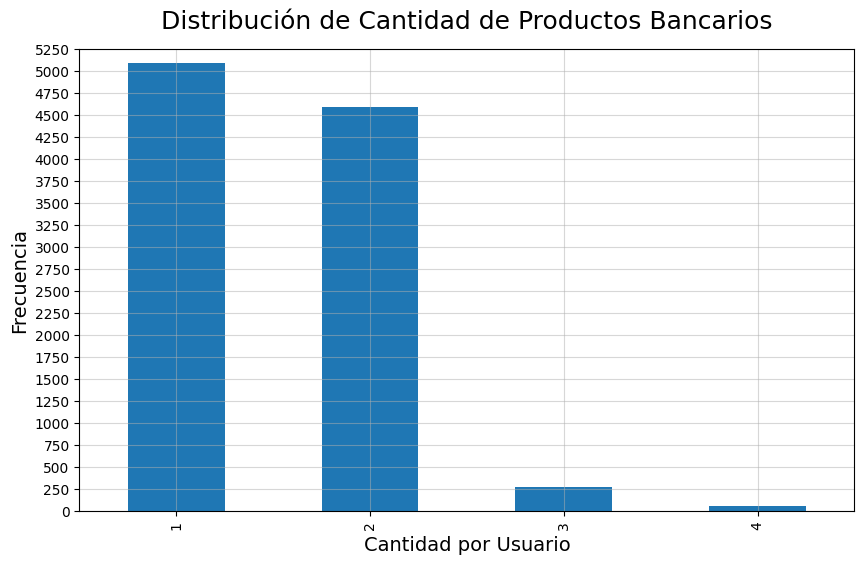

In [10]:
print(df['NumOfProducts'].unique(), '\n')
print(df['NumOfProducts'].describe(), '\n')
print(f"""Moda de número de productos: {df['NumOfProducts'].mode().iloc[0]}""") # Solo había un valor, así que use iloc para obtener el número solamente.

df['NumOfProducts'].value_counts().sort_index().plot(
    figsize=(10, 6),
    kind='bar',
    ylim=[0,1000]
)
plt.title('Distribución de Cantidad de Productos Bancarios', fontsize=18, pad=15)
plt.xlabel('Cantidad por Usuario', fontsize=14)
plt.ylabel('Frecuencia', fontsize=14)
plt.grid(alpha=0.5)
plt.yticks(np.arange(0, 5400, 250))
plt.show()

In [11]:
print(df['HasCrCard'].describe(), '\n')

count    10000.00000
mean         0.70550
std          0.45584
min          0.00000
25%          0.00000
50%          1.00000
75%          1.00000
max          1.00000
Name: HasCrCard, dtype: float64 



In [12]:
print(df['IsActiveMember'].describe(), '\n')

count    10000.000000
mean         0.515100
std          0.499797
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: IsActiveMember, dtype: float64 



In [13]:
print(df['EstimatedSalary'].describe(), '\n')

count     10000.000000
mean     100090.239881
std       57510.492818
min          11.580000
25%       51002.110000
50%      100193.915000
75%      149388.247500
max      199992.480000
Name: EstimatedSalary, dtype: float64 



In [14]:
print(df['Exited'].describe(), '\n')

count    10000.000000
mean         0.203700
std          0.402769
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: Exited, dtype: float64 



Primeras impresiones:
- La columna "RowNumber" es inservible al contar con un índice, la podemos eliminar para que no influya en el modelo.
- La columna de CustomerId es redundante al ser valores únicos (no hay duplicados). Cumple la misma función que el índice y por eso se puede eliminar.
- Para el appellido (Surname), el cual sí tiene valores duplicados, tiene más de 2,000 valores únicos. Utilizarlos para entrenar el modelo no sería prácitco y dudo que tenga relevancia significativa, así que también eliminaré esa columna.
    - De haber muchos menos valores únicos, la podríamos mantener para ver si casualmente existe una correlación con algún apellido, al fin y al cabo en la vida real es común que los familiares recomienden e influyan en las decisiones de sus congéneres.
- Los **valores nulos** de longevidad (Tenure) serán eliminados para tener una base de datos consistente, ya que en general los años de tenencia tienen una frecuencia muy similar (salvo por años 0 y 10). También se podría asignar valores aleatorios entre 1 y 9 dada la distribución, pero esto podría ser errado si existe una correlación fuerte de algún valor específico con la salida del cliente.
- El saldo tiene un coeficiente de variación mayor a 30%, y por lo tanto es de **alta variabilidad relativa**.
- Como es de esperarse, la mayoría de los usuarios tienen 1 solo producto, aunque los que tienen 2 no se quedan muy atras.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - El análisis exploratorio está bien estructurado y permite comprender con claridad las características del conjunto de datos, facilitando una base sólida para las decisiones posteriores en el modelado.
</div>


### Preparación de Datos

In [15]:
datos00 = df.drop(['Surname','RowNumber', 'CustomerId'], axis=1) # Elimino columnas irrelevantes.
datos = datos00[pd.to_numeric(datos00['Tenure'], errors='coerce').notnull()] # Elimino filas con valores nulos en tenencia.

print(datos.info(), '\n')
datos.head()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9091 entries, 0 to 9998
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      9091 non-null   int64  
 1   Geography        9091 non-null   object 
 2   Gender           9091 non-null   object 
 3   Age              9091 non-null   int64  
 4   Tenure           9091 non-null   float64
 5   Balance          9091 non-null   float64
 6   NumOfProducts    9091 non-null   int64  
 7   HasCrCard        9091 non-null   int64  
 8   IsActiveMember   9091 non-null   int64  
 9   EstimatedSalary  9091 non-null   float64
 10  Exited           9091 non-null   int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 852.3+ KB
None 



,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


## Modelo

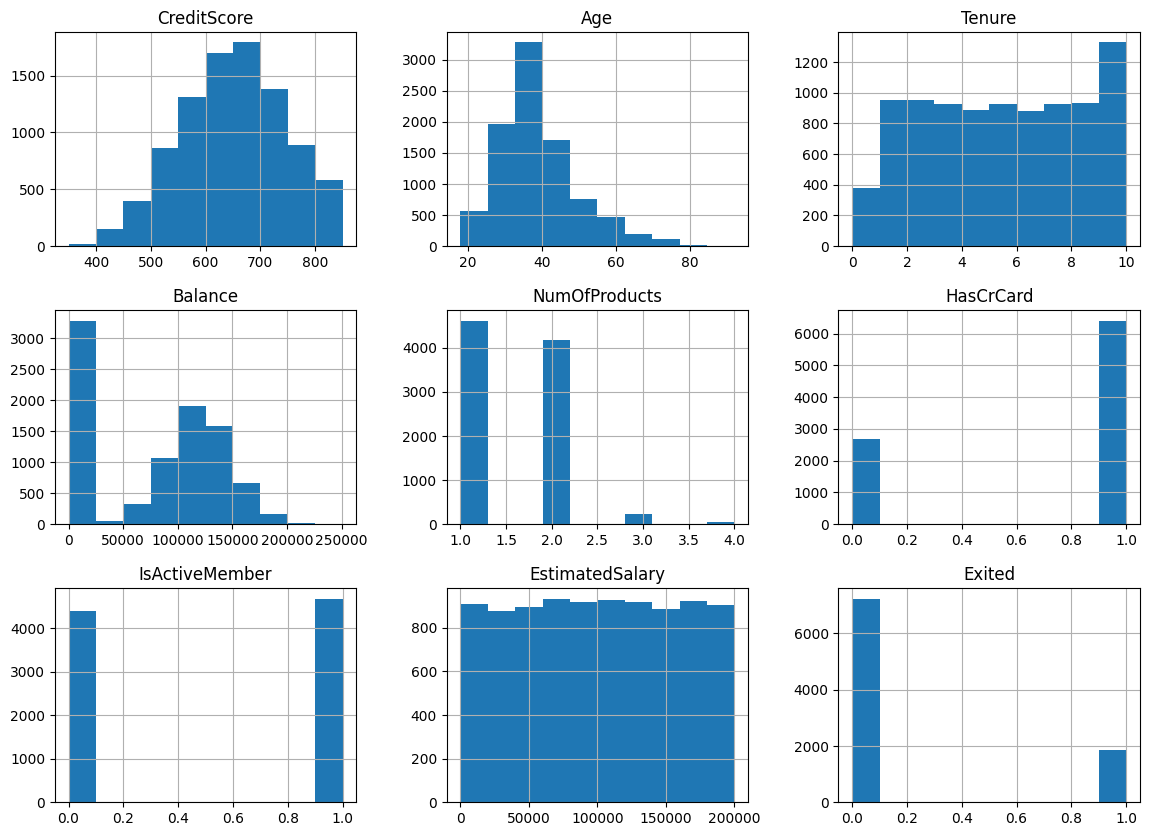

In [16]:
# Visualizo el tipo de destribución de cada columna numérica.

datos.hist(figsize=(14, 10))
plt.show()

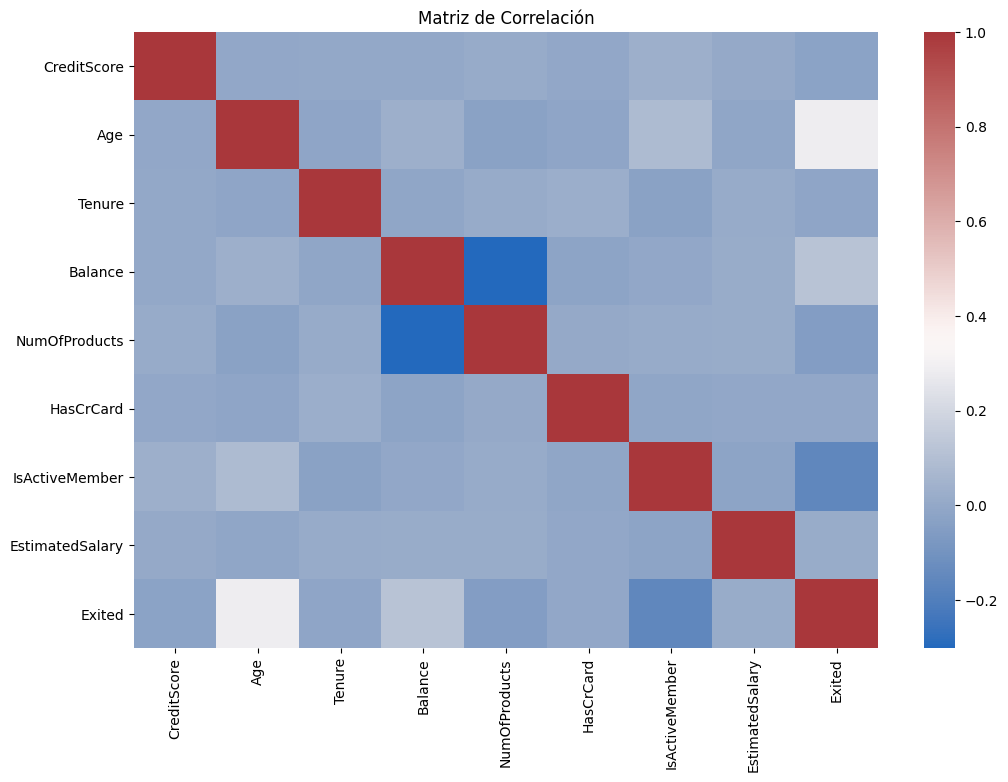

                 CreditScore       Age    Tenure   Balance  NumOfProducts  \
CreditScore         1.000000 -0.004504 -0.000062  0.002804       0.011090   
Age                -0.004504  1.000000 -0.013134  0.031481      -0.031877   
Tenure             -0.000062 -0.013134  1.000000 -0.007911       0.011979   
Balance             0.002804  0.031481 -0.007911  1.000000      -0.301858   
NumOfProducts       0.011090 -0.031877  0.011979 -0.301858       1.000000   
HasCrCard          -0.003937 -0.014129  0.027232 -0.019055       0.005805   
IsActiveMember      0.030947  0.082269 -0.032178 -0.003285       0.009084   
EstimatedSalary     0.005182 -0.007037  0.010520  0.014351       0.013990   
Exited             -0.023950  0.283017 -0.016761  0.117218      -0.050271   

                 HasCrCard  IsActiveMember  EstimatedSalary    Exited  
CreditScore      -0.003937        0.030947         0.005182 -0.023950  
Age              -0.014129        0.082269        -0.007037  0.283017  
Tenure       

In [17]:
# Matriz de Correlación.

datos_corr = datos.corr()

plt.figure(figsize = (12, 8))
sns.heatmap(datos_corr, cmap = 'vlag', fmt = '.2f')
plt.title('Matriz de Correlación')
plt.show()

print(datos_corr)

No aparecen algunas de las variables de categoría porque aún no estandarizo.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - La exploración visual y el análisis de correlaciones aportan una comprensión clara de las relaciones entre variables, lo que respalda de forma sólida las decisiones posteriores en el modelado
</div>


### Preprocesamiento: Dummies

In [18]:
# Hago que las columnas de Geography y Gender se conviertan en números.
# Como Geography tiene 3 valores diferentes y Gender 2, se pueden transformar con OHE.

datos_enc00 = pd.get_dummies(datos, columns=['Geography', 'Gender'], drop_first=True)
datos_enc00.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2.0,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1.0,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8.0,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1.0,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2.0,125510.82,1,1,1,79084.10,0,0,1,0


In [19]:
# Divido los datos en características y objetivo.

features = datos_enc00.drop(['Exited'], axis = 1)
target = datos_enc00['Exited']

X_train, X_valid, y_train, y_valid = train_test_split(features, target, test_size = 0.3, random_state = random_state)
datos_split = [X_train, X_valid, y_train, y_valid]
for ds in datos_split:
    print(ds.head(), '\n\n')

      CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
8486          738   40     6.0  114940.67              2          1   
4249          531   44     3.0       0.00              2          1   
7324          607   39    10.0       0.00              3          1   
9057          704   33     0.0  130499.09              2          1   
5321          732   25     0.0  110942.90              1          0   

      IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  \
8486               1        194895.57                  1                0   
4249               1         34416.79                  0                0   
7324               0        132741.13                  0                0   
9057               1         74804.36                  0                0   
5321               0        172576.56                  0                0   

      Gender_Male  
8486            0  
4249            1  
7324            0  
9057            0  
5321      

### Entrenamiento de Modelos (sin equilibrar)

In [20]:
# Entrenado, F1, y AUC-ROC: RandomForestClassifier

n_estimadores = np.arange(40, 70, 4)
profundidades = [None, 5, 10, 50]

rfc_mejor_score = 0
rfc_mejores_parametros = {}
rfc_mejor_ra_score = 0
rfc_mejor_f1_score = 0
rfc_conteo = 1
# Iterado de hiperparámetros:

for n in n_estimadores:
    for p in profundidades:
        rfc_modelo = RandomForestClassifier(
            n_estimators = n,
            max_depth = p,
            random_state = random_state
        )
        rfc_modelo.fit(X_train, y_train)

# Evaluado de iteración:
        y_pred = rfc_modelo.predict(X_valid)
        y_proba = rfc_modelo.predict_proba(X_valid)[:, 1] # Probabilidad de Exited = 1.
        rfc_score = accuracy_score(y_valid, y_pred)
        rfc_ra_score = roc_auc_score(y_valid, y_proba)
        rfc_f1_score = f1_score(y_valid, y_pred)
        
        print(f'Iteración #{rfc_conteo}:\tEstimadores = {n} \tProfundidad = {p} \tExactitud = {rfc_score:.4f}\tAUC-ROC = {rfc_ra_score:.4f}\tF1-Score = {rfc_f1_score:.4f}')
        rfc_conteo += 1

# Mejor valor en base a Exactitud:
        if rfc_score > rfc_mejor_score:
            rfc_mejor_score = rfc_score
            rfc_mejores_parametros = {'Número de Estimadores': n, 'Profundidad': p}
            rfc_mejor_ra_score = rfc_ra_score
            rfc_mejor_f1_score = rfc_f1_score

print(f'\nResultado sin equilibrar datos:')
print(f'Mejor exactitud (accuracy): {rfc_mejor_score:.4f}')
print(f'Mejores hiperparámetros: {rfc_mejores_parametros}')
print(f'AUC-ROC = {rfc_mejor_ra_score:.4f}\tF1-Score = {rfc_mejor_f1_score:.4f}')

Iteración #1:	Estimadores = 40 	Profundidad = None 	Exactitud = 0.8600	AUC-ROC = 0.8380	F1-Score = 0.5688
Iteración #2:	Estimadores = 40 	Profundidad = 5 	Exactitud = 0.8486	AUC-ROC = 0.8386	F1-Score = 0.4779
Iteración #3:	Estimadores = 40 	Profundidad = 10 	Exactitud = 0.8592	AUC-ROC = 0.8545	F1-Score = 0.5461
Iteración #4:	Estimadores = 40 	Profundidad = 50 	Exactitud = 0.8600	AUC-ROC = 0.8380	F1-Score = 0.5688
Iteración #5:	Estimadores = 44 	Profundidad = None 	Exactitud = 0.8589	AUC-ROC = 0.8400	F1-Score = 0.5660
Iteración #6:	Estimadores = 44 	Profundidad = 5 	Exactitud = 0.8486	AUC-ROC = 0.8406	F1-Score = 0.4698
Iteración #7:	Estimadores = 44 	Profundidad = 10 	Exactitud = 0.8607	AUC-ROC = 0.8561	F1-Score = 0.5561
Iteración #8:	Estimadores = 44 	Profundidad = 50 	Exactitud = 0.8589	AUC-ROC = 0.8400	F1-Score = 0.5660
Iteración #9:	Estimadores = 48 	Profundidad = None 	Exactitud = 0.8592	AUC-ROC = 0.8412	F1-Score = 0.5646
Iteración #10:	Estimadores = 48 	Profundidad = 5 	Exactitud 

Este modelo no satisface los requisitos, ya que tiene un F1-Score menor a 0.59.

Probablemente mejore después de estandarizar y equilibrar los datos.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - El proceso de entrenamiento y evaluación de modelos está bien estructurado, mostrando una exploración sólida de hiperparámetros y métricas clave que permiten entender claramente el desempeño inicial de los modelos.
</div>


In [21]:
# Entrenado, F1, y AUC-ROC: LogisticRegression

lg_modelo = LogisticRegression(
    solver = 'liblinear',
    random_state = random_state
)

lg_modelo.fit(X_train, y_train)
y_pred = lg_modelo.predict(X_valid)
y_proba = lg_modelo.predict_proba(X_valid)[:, 1]
lg_score = accuracy_score(y_valid, y_pred) #****************
lg_ra_score = roc_auc_score(y_valid, y_proba)
lg_f1_score = f1_score(y_valid, y_pred)

print(f'''Resultado sin equilibrar:
Exactitud (accuracy):\t{lg_score:.4f}
AUC-ROC = \t\t{lg_ra_score:.4f}
F1-Score =\t\t{lg_f1_score:.4f}''')

Resultado sin equilibrar:
Exactitud (accuracy):	0.7966
AUC-ROC = 		0.6711
F1-Score =		0.1315


De igual manera, este modelo es malo. Es aún peor que el anterior.

Después de estandarizar y escalar, probablemente mejorará el resultado.

### Preprocesamiento: Escalado y Estandarizado

In [22]:
# Al haber outliers fuertes, sobre todo en la columna de 'Balance', utilizaré 'RobustScaler' para que no afecten.
# Utilizaré 'ColumnTransformer' para no tener que separar y volver a unir las columnas escaladas.

columnas_rs = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']
columnas_nrs = [cols for cols in datos_enc00.columns if cols not in columnas_rs]

transformador = ColumnTransformer(
    transformers = [
        ('robust',
         RobustScaler(),
         columnas_rs
        )
    ],
    remainder = 'passthrough'
)

datos_enc01 = transformador.fit_transform(datos_enc00)

datos_02 = pd.DataFrame(
    datos_enc01,
    columns=columnas_rs + columnas_nrs
)

print(datos_02.describe(), '\n\n')
datos_02.head()

       CreditScore          Age       Tenure      Balance  EstimatedSalary  \
count  9091.000000  9091.000000  9091.000000  9091.000000      9091.000000   
mean     -0.009500     0.162432    -0.000462    -0.163023        -0.000600   
std       0.724891     0.879632     0.578945     0.488622         0.585978   
min      -2.270677    -1.583333    -1.000000    -0.762910        -1.019211   
25%      -0.511278    -0.416667    -0.600000    -0.762910        -0.498401   
50%       0.000000     0.000000     0.000000     0.000000         0.000000   
75%       0.488722     0.583333     0.400000     0.237090         0.501599   
max       1.488722     4.583333     1.000000     1.203963         1.014367   

       NumOfProducts    HasCrCard  IsActiveMember       Exited  \
count    9091.000000  9091.000000     9091.000000  9091.000000   
mean        1.530195     0.704983        0.515565     0.203938   
std         0.581003     0.456076        0.499785     0.402946   
min         1.000000     0.000000

,CreditScore,Age,Tenure,Balance,EstimatedSalary,NumOfProducts,HasCrCard,IsActiveMember,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,-0.248120,0.416667,-0.6,-0.762910,0.011274,1.0,1.0,1.0,1.0,0.0,0.0,0.0
1,-0.330827,0.333333,-0.8,-0.105912,0.125101,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,-1.127820,0.416667,0.6,0.488724,0.139226,3.0,1.0,0.0,1.0,0.0,0.0,0.0
3,0.353383,0.166667,-0.8,-0.762910,-0.065219,2.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.488722,0.500000,-0.6,0.221011,-0.215133,1.0,1.0,1.0,0.0,0.0,1.0,0.0


<span style="color:red">**NOTA:**</span> Como el resultado del RobustScaler creó valores dentro del rango de -2.2706 y 4.5833, estos datos pueden utilizarse tanto para el modelo de RandomForest como en las Regresiones Logística y Lineal, ya que este rango es muy similar al de una distribución normal y no debería de perjudicar significativamente la precisión de los modelos de regresión.
- Dicho esto, la comparación de coeficientes entre variables binarias y el resto sí es afectada por la naturaleza de la información.
- El RandomForest no será afectado negativamente.

In [23]:
y_ratio = (datos_02['Exited'].sum())/datos_02['Exited'].count()*100
print(f'Valores positivos de "Exited" = {y_ratio:.2f}%')

Valores positivos de "Exited" = 20.39%


Como solo hay 20.39% de valores positivos en la variable dependiente en los datos, se requiere un balanceo de clase.

En este caso, haré un submuestreo. Habría elegido SMOTE pero la plataforma no me permite instalar 'imbalanced-learn'

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - La aplicación del escalado junto con el análisis del desbalance de clases muestra un razonamiento claro y bien fundamentado que fortalece la preparación del modelo para etapas más avanzadas
</div>


In [24]:
# Submuestreo.

print(f'''Datos negativos y positivos pre-submuestreo:
\tExited negativo = {datos_02['Exited'][datos_02['Exited']==0].count()}
\tExited positivo = {datos_02['Exited'][datos_02['Exited']==1].count()}
\tProporción = {datos_02['Exited'][datos_02['Exited']==1].count()/datos_02['Exited'][datos_02['Exited']==0].count()*100:.2f}%
''')

datos_enc = pd.concat(
    [
        datos_02[datos_02['Exited']==0].sample(
            n=len(datos_02[datos_02['Exited']==1]
                 ),
            random_state = random_state
        ),
    datos_02[datos_02['Exited']==1]
    ]
)

print(f'''Datos negativos y positivos post-submuestreo:
\tExited negativo = {datos_enc['Exited'][datos_enc['Exited']==0].count()}
\tExited positivo = {datos_enc['Exited'][datos_enc['Exited']==1].count()}
\tProporción = {datos_enc['Exited'][datos_enc['Exited']==1].count()/datos_enc['Exited'][datos_enc['Exited']==0].count()*100:.2f}%
''')

Datos negativos y positivos pre-submuestreo:
	Exited negativo = 7237
	Exited positivo = 1854
	Proporción = 25.62%

Datos negativos y positivos post-submuestreo:
	Exited negativo = 1854
	Exited positivo = 1854
	Proporción = 100.00%



In [25]:
# Divido los datos en características y objetivo.

features = datos_enc.drop(['Exited'], axis = 1)
target = datos_enc['Exited']

X_train, X_valid, y_train, y_valid = train_test_split(features, target, test_size = 0.3, random_state = random_state)
datos_split = [X_train, X_valid, y_train, y_valid]
for ds in datos_split:
    print(ds.head(), '\n\n')

      CreditScore       Age  Tenure   Balance  EstimatedSalary  NumOfProducts  \
1562    -0.383459  0.583333    -0.2 -0.762910        -0.423827            2.0   
8374    -0.496241 -0.833333     0.0  0.258020         0.937436            2.0   
3155    -0.819549  0.000000    -0.4 -0.762910        -0.216846            2.0   
7371    -0.090226  0.500000     0.8 -0.020114         0.851806            1.0   
3274     0.586466 -0.333333    -1.0 -0.762910        -1.004331            2.0   

      HasCrCard  IsActiveMember  Geography_Germany  Geography_Spain  \
1562        1.0             0.0                0.0              1.0   
8374        1.0             1.0                0.0              0.0   
3155        1.0             1.0                0.0              1.0   
7371        1.0             0.0                1.0              0.0   
3274        1.0             0.0                0.0              0.0   

      Gender_Male  
1562          0.0  
8374          1.0  
3155          1.0  
7371  

Entrenaré un modelo de RandomForestClassifier, y otro de LogisticRegression para compararlos.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - La estrategia de submuestreo está bien aplicada y permite lograr un balance adecuado de clases, lo que fortalece significativamente la capacidad del modelo para aprender patrones relevantes
</div>


### Entrenamiento de Modelos (equilibrado)

In [32]:
# Entrenado, F1, y AUC-ROC: RandomForestClassifier

n_estimadores = np.arange(40, 70, 4)
profundidades = [None, 5, 10, 50]

rfc_mejor_score = 0
rfc_mejores_parametros = {}
rfc_mejor_ra_score = 0
rfc_mejor_f1_score = 0
rfc_conteo = 1
rfc_mejor_pred = []
# Iterado de hiperparámetros:

for n in n_estimadores:
    for p in profundidades:
        rfc_modelo = RandomForestClassifier(
            n_estimators = n,
            max_depth = p,
            random_state = random_state
        )
        rfc_modelo.fit(X_train, y_train)

# Evaluado de iteración:
        y_pred = rfc_modelo.predict(X_valid)
        y_proba = rfc_modelo.predict_proba(X_valid)[:, 1] # Probabilidad de Exited = 1.
        rfc_score = accuracy_score(y_valid, y_pred)
        rfc_ra_score = roc_auc_score(y_valid, y_proba)
        rfc_f1_score = f1_score(y_valid, y_pred)
        
        print(f'Iteración #{rfc_conteo}:\tEstimadores = {n} \tProfundidad = {p} \tExactitud = {rfc_score:.4f}\tAUC-ROC = {rfc_ra_score:.4f}\tF1-Score = {rfc_f1_score:.4f}')
        rfc_conteo += 1

# Mejor valor en base a Exactitud:
        if rfc_score > rfc_mejor_score:
            rfc_mejor_score = rfc_score
            rfc_mejores_parametros = {'Número de Estimadores': n, 'Profundidad': p}
            rfc_mejor_ra_score = rfc_ra_score
            rfc_mejor_f1_score = rfc_f1_score
            rfc_mejor_pred = y_pred

print(f'\nResultado:')
print(f'Mejor exactitud (accuracy): {rfc_mejor_score:.4f}')
print(f'Mejores hiperparámetros: {rfc_mejores_parametros}')
print(f'AUC-ROC = {rfc_mejor_ra_score:.4f}\tF1-Score = {rfc_mejor_f1_score:.4f}')

Iteración #1:	Estimadores = 40 	Profundidad = None 	Exactitud = 0.7682	AUC-ROC = 0.8350	F1-Score = 0.7646
Iteración #2:	Estimadores = 40 	Profundidad = 5 	Exactitud = 0.7592	AUC-ROC = 0.8348	F1-Score = 0.7541
Iteración #3:	Estimadores = 40 	Profundidad = 10 	Exactitud = 0.7673	AUC-ROC = 0.8429	F1-Score = 0.7608
Iteración #4:	Estimadores = 40 	Profundidad = 50 	Exactitud = 0.7682	AUC-ROC = 0.8350	F1-Score = 0.7646
Iteración #5:	Estimadores = 44 	Profundidad = None 	Exactitud = 0.7655	AUC-ROC = 0.8349	F1-Score = 0.7616
Iteración #6:	Estimadores = 44 	Profundidad = 5 	Exactitud = 0.7655	AUC-ROC = 0.8351	F1-Score = 0.7603
Iteración #7:	Estimadores = 44 	Profundidad = 10 	Exactitud = 0.7673	AUC-ROC = 0.8441	F1-Score = 0.7617
Iteración #8:	Estimadores = 44 	Profundidad = 50 	Exactitud = 0.7655	AUC-ROC = 0.8349	F1-Score = 0.7616
Iteración #9:	Estimadores = 48 	Profundidad = None 	Exactitud = 0.7673	AUC-ROC = 0.8369	F1-Score = 0.7630
Iteración #10:	Estimadores = 48 	Profundidad = 5 	Exactitud 

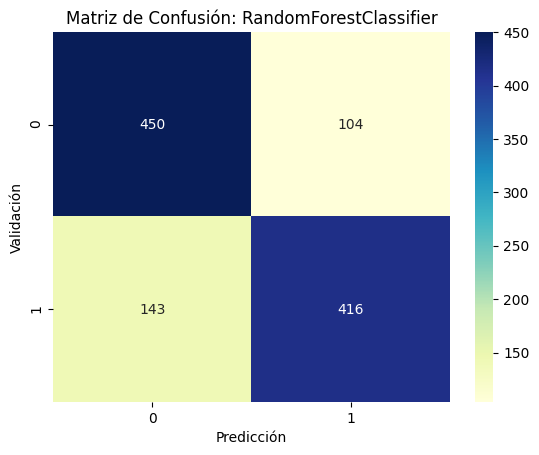

In [43]:
rfc_cm = confusion_matrix(y_valid, rfc_mejor_pred)
sns.heatmap(rfc_cm, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Matriz de Confusión: RandomForestClassifier')
plt.xlabel('Predicción')
plt.ylabel('Validación')
plt.show()

El modelo RandomForestClassifier con los parámetros óptimos han dado buenos valores tanto para el AUC-ROC como para el F1-Score.
- Significa que el modelo tiene una buena capacidad de reconocimiento de patrones (buen AUC-ROC).
- Y que es un modelo decente para predecir los valores positivos.

In [44]:
# Entrenado, F1, y AUC-ROC: LogisticRegression

lg_modelo = LogisticRegression(
    solver = 'liblinear',
    random_state = random_state
)

lg_modelo.fit(X_train, y_train)
y_pred = lg_modelo.predict(X_valid)
y_proba = lg_modelo.predict_proba(X_valid)[:, 1]
lg_score = accuracy_score(y_valid, y_pred) #****************
lg_ra_score = roc_auc_score(y_valid, y_proba)
lg_f1_score = f1_score(y_valid, y_pred)

print(f'''Resultado:
Exactitud (accuracy):\t{lg_score:.4f}
AUC-ROC = \t\t{lg_ra_score:.4f}
F1-Score =\t\t{lg_f1_score:.4f}''')

Resultado:
Exactitud (accuracy):	0.6909
AUC-ROC = 		0.7641
F1-Score =		0.6856


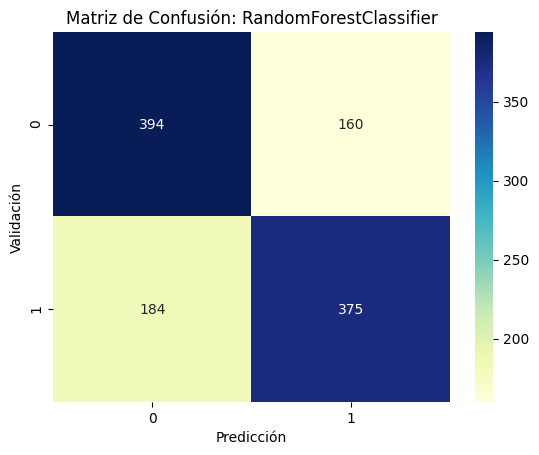

In [45]:
lr_cm = confusion_matrix(y_valid, y_pred)
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Matriz de Confusión: RandomForestClassifier')
plt.xlabel('Predicción')
plt.ylabel('Validación')
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - El entrenamiento con datos equilibrados evidencia una mejora clara en el desempeño del modelo, reflejando un enfoque sólido en la optimización y evaluación mediante métricas relevantes.
</div>


## Conclusiones

Definitivamente la estandarización y escalación de los datos es escencial para poder desarrollar modelos útiles.

Entre los modelos de LogisticRegression y RandomForestClassifier, éste último fue el mejor.

En base a los valores de AUC-ROC y F1-Score del modelo ganador, se puede decir que es un modelo muy bueno y consistente, ya que tiene una probabilidad de 84.5% de asignar una puntuación más alta a características que contengan el valor 1 en "Exited".

Al tener un F1 de 0.77, se puede decir que el modelo tiene un buen equilibrio para evitar dar flasos positivos (precisión) y acierta en los verdaderos positivos la mayoría de las veces (sensibilidad, o recall).

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - Las conclusiones reflejan una interpretación clara y coherente de los resultados, conectando adecuadamente las métricas con el desempeño del modelo final
</div>


# Comentario General del Revisor

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

El proyecto muestra un desarrollo ordenado y bien articulado, cubriendo todas las etapas clave del flujo de machine learning. Se evidencia una comprensión clara del problema y una ejecución consistente desde la preparación de datos hasta la evaluación final del modelo.

#### Puntos Positivos:

* **Procesamiento de datos:** Se realiza una limpieza adecuada, eliminando variables irrelevantes y tratando valores nulos de forma coherente para mantener la calidad del dataset.
* **Análisis exploratorio:** El análisis inicial permite entender correctamente la distribución de las variables y sus relaciones, lo que respalda las decisiones posteriores.
* **Preparación de datos:** La codificación de variables categóricas y el uso de escalado robusto reflejan un manejo adecuado de diferentes tipos de datos y presencia de outliers.
* **Manejo del desbalance:** Se identifica correctamente el desbalance de clases y se aplica una estrategia de submuestreo efectiva, cumpliendo con los requisitos del proyecto.
* **Comparación de modelos:** Se entrenan y evalúan distintos modelos, incluyendo ajuste de hiperparámetros, utilizando métricas relevantes como F1 y AUC-ROC.
* **Resultados del modelo:** Se alcanza un F1-Score superior a 0.59, cumpliendo el objetivo principal, acompañado de un AUC-ROC sólido que respalda la capacidad predictiva del modelo.
* **Interpretación de resultados:** Las conclusiones conectan correctamente las métricas con el desempeño del modelo, mostrando una comprensión adecuada del problema.

El proyecto cumple con todos los requisitos planteados y demuestra un enfoque sólido en el desarrollo de modelos predictivos, con decisiones bien fundamentadas en cada etapa.

</div>
